In [1]:
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from uncertainties import ufloat
from ctypes import c_double
from pathlib import Path
import pickle

# import ROOT
# ROOT.EnableImplicitMT()    # Tells ROOT to go parallel

/groups/hephy/cms/alikaan.gueven/conda/envs/SDV/lib/python3.11/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [42]:
# HISTDIR = Path('/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/vtx_PART_1111best_valloss_epoch_multiplane_dphi_test6/tables')
HISTDIR = Path('/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/plotconfig_Run2_goodtk_first/tables')

PLANEs = ['SP0', 'SP1', 'SP2', 'SP3']
METCUT = 'MET350'
# PLANEs = ['CP0', 'CP1', 'CP2', 'CP3']
tables = {}

for PLANE in PLANEs:
    # SAMPLE = f'stopML_M1000_975_ct0p2_2018_{METCUT}{PLANE}_evt_leading_vtx_{PLANE}_dphiMET_vs_{PLANE}_Max_ML_score'
    SAMPLE = f'C1N2ML_M200_195_ct20_2018_{METCUT}{PLANE}_evt_leading_vtx_{PLANE}_dphiMET_vs_{PLANE}_Max_ML_score'
    loCut_key = '0.00,0.00'

    TABLE = 'gridsearch_disco.pkl'
    TABLE_PATH = HISTDIR / SAMPLE / TABLE

    with open(TABLE_PATH, 'rb') as f:
        table = pickle.load(f)
    
    tables[PLANE] = table

    print('Keys in the loaded table:')
    for key in table.keys():
        print(key)


Keys in the loaded table:
0.00,0.00
Keys in the loaded table:
0.00,0.00
Keys in the loaded table:
0.00,0.00
Keys in the loaded table:
0.00,0.00


In [43]:
print("Kaan bkg")
for PLANE in PLANEs:
    print("PLANE: ", PLANE)
    print("Ang's A: ", tables[PLANE]['0.00,0.00']['bkg_NB'].loc[1.5,0.9990] * (59.683 / 273))
    print("Ang's B: ", tables[PLANE]['0.00,0.00']['bkg_ND'].loc[1.5,0.9990] * (59.683 / 273))
    print("Ang's C: ", tables[PLANE]['0.00,0.00']['bkg_NA'].loc[1.5,0.9990] * (59.683 / 273))
    print("Ang's D: ", tables[PLANE]['0.00,0.00']['bkg_NC'].loc[1.5,0.9990] * (59.683 / 273))

Kaan bkg
PLANE:  SP0
Ang's A:  0.9677275316250858
Ang's B:  6840.2954838926125
Ang's C:  0.8066037694578656
Ang's D:  8784.665138511467
PLANE:  SP1
Ang's A:  1.8859143172065882
Ang's B:  8017.80932737609
Ang's C:  0.7894714823082778
Ang's D:  9353.46060535564
PLANE:  SP2
Ang's A:  1.7065787079686043
Ang's B:  3538.4514789078116
Ang's C:  1.4380814876885248
Ang's D:  3845.8497538212823
PLANE:  SP3
Ang's A:  -1.2197775829956883
Ang's B:  275.43494420229314
Ang's C:  0.9647884751194084
Ang's D:  273.05775555688325


In [45]:
print("Kaan sig")
for PLANE in PLANEs:
    print("PLANE: ", PLANE)
    print("Ang's A: ", tables[PLANE]['0.00,0.00']['sig_NB'].loc[1.5,0.9990] * (59.683 / 273) * 1807)
    print("Ang's B: ", tables[PLANE]['0.00,0.00']['sig_ND'].loc[1.5,0.9990] * (59.683 / 273) * 1807)
    print("Ang's C: ", tables[PLANE]['0.00,0.00']['sig_NA'].loc[1.5,0.9990] * (59.683 / 273) * 1807)
    print("Ang's D: ", tables[PLANE]['0.00,0.00']['sig_NC'].loc[1.5,0.9990] * (59.683 / 273) * 1807)

Kaan sig
PLANE:  SP0
Ang's A:  0.8685150787214404
Ang's B:  42.35741029590544
Ang's C:  0.0
Ang's D:  38.516178756680915
PLANE:  SP1
Ang's A:  0.8668832973221307
Ang's B:  77.08990008577629
Ang's C:  0.0
Ang's D:  48.02973205191781
PLANE:  SP2
Ang's A:  3.4766425180825697
Ang's B:  69.95239627513028
Ang's C:  0.0
Ang's D:  26.866098057624136
PLANE:  SP3
Ang's A:  4.24123238765935
Ang's B:  11.435524585969342
Ang's C:  0.0
Ang's D:  0.8126256487611743


In [34]:
for PLANE in PLANEs:
    Z_As = tables[PLANE][loCut_key]['Z_A']

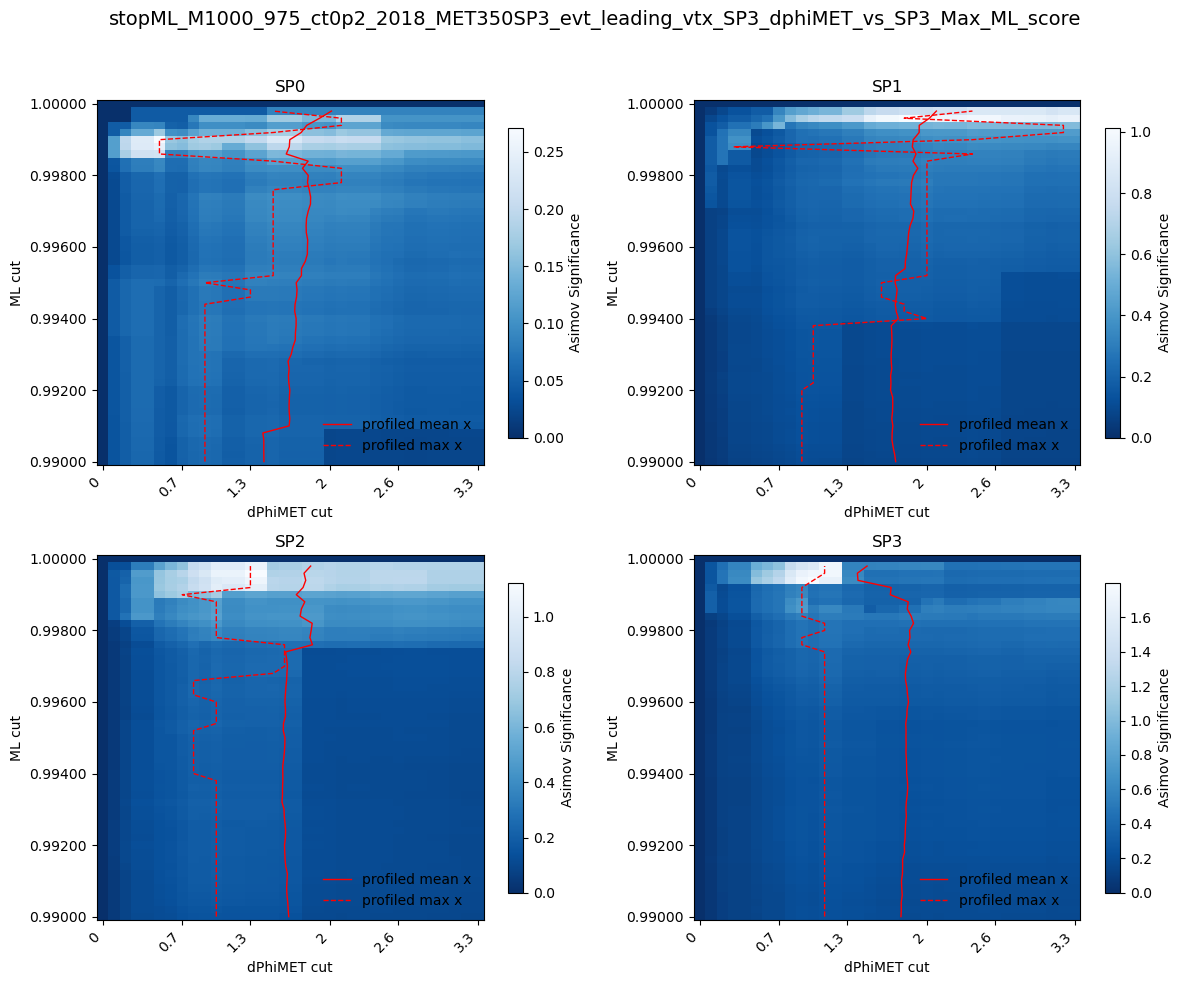

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

def pick_ticks(vals, n=6):
    vals = np.asarray(list(vals), dtype=float)
    if len(vals) <= n:
        return vals
    idx = np.unique(np.round(np.linspace(0, len(vals)-1, n)).astype(int))
    idx[0] = 0
    idx[-1] = len(vals) - 1
    return vals[idx]

def edges_from_centers(c):
    c = np.asarray(c, dtype=float)
    d = np.diff(c)
    e = np.empty(len(c) + 1)
    e[1:-1] = c[:-1] + d / 2
    e[0]  = c[0]  - d[0] / 2
    e[-1] = c[-1] + d[-1] / 2
    return e

def profile_x_mean_and_max(x, C):
    """
    For each y-bin (row of C), return:
      - x_mean(y): weighted mean of x using weights=C[y,x] (clipped to >=0), NaNs ignored
      - x_max(y): x position of maximum (argmax of weights), NaNs ignored
    C shape: (Ny, Nx), x shape: (Nx,)
    """
    x = np.asarray(x, dtype=float)
    C = np.asarray(C, dtype=float)

    w = np.where(np.isfinite(C), np.clip(C, 0.0, None), np.nan)  # keep NaN for max logic
    w0 = np.where(np.isfinite(w), w, 0.0)                        # for sums/means

    sw = w0.sum(axis=1)                                          # (Ny,)
    x_mean = np.divide((w0 * x[None, :]).sum(axis=1), sw,
                       out=np.full(C.shape[0], np.nan, dtype=float),
                       where=sw > 0)

    # max position per row (y)
    w_for_argmax = np.where(np.isfinite(w), w, -np.inf)
    imax = np.argmax(w_for_argmax, axis=1)                       # (Ny,)
    row_max = np.max(w_for_argmax, axis=1)
    x_max = np.where(np.isfinite(row_max) & (row_max > 0), x[imax], np.nan)

    return x_mean, x_max


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, ZK in zip(axes, PLANEs[:]):

    X_b = tables[ZK][key]['Z_B']
    # X_b = X_b.loc[0:, 0:0.80]
    X_b = X_b.loc[0:, 0.990:]
    X_b = X_b.fillna(0)

    x = X_b.index.to_numpy(dtype=float)
    y = X_b.columns.to_numpy(dtype=float)

    x_edges = edges_from_centers(x)
    y_edges = edges_from_centers(y)

    C = X_b.T.to_numpy()   # (Ny, Nx)
    absmax = np.nanmax(np.abs(C))

    pcm = ax.pcolormesh(
        x_edges, y_edges, C,
        cmap="Blues_r",
        vmin=0,
        vmax=absmax,
        shading="flat"
    )

    # --- single x value for every y: mean (solid) and max (dashed) ---
    x_mean, x_max = profile_x_mean_and_max(x, C)

    m_mean = np.isfinite(x_mean)
    m_max  = np.isfinite(x_max)

    ax.plot(x_mean[m_mean], y[m_mean], "r-",  lw=1.0, zorder=6, label="profiled mean x")
    ax.plot(x_max[m_max],   y[m_max],  "r--", lw=1.0, zorder=6, label="profiled max x")

    ax.set_xticks(pick_ticks(x, 6))
    ax.set_yticks(pick_ticks(y, 6))

    ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()],
                       rotation=45, ha="right")
    ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

    ax.set_xlabel("dPhiMET cut")
    ax.set_ylabel("ML cut")
    ax.set_title(ZK)

    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.5f'))

    ax.legend(frameon=False, loc="lower right")

    cbar = fig.colorbar(pcm, ax=ax, shrink=0.85)
    cbar.ax.set_ylabel("Asimov Significance")

fig.suptitle(SAMPLE, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [5]:
tables['SP3'][key]['sig_NB'].loc[0.7:1.6,0.999:]

,0.9990,0.9992,0.9994,0.9996,0.9998,1.0000
0.7,2.139321,2.017032,1.893206,1.646614,1.311765,0.0
0.8,2.670784,2.548495,2.424670,2.178078,1.843229,0.0
0.9,3.042905,2.879717,2.715211,2.468619,2.089300,0.0
1.0,3.166168,3.002980,2.838475,2.591883,2.212564,0.0
1.1,3.570380,3.407192,3.202318,2.955726,2.576406,0.0
1.2,3.570380,3.407192,3.202318,2.955726,2.576406,0.0
1.3,3.697915,3.534727,3.329852,3.083260,2.703941,0.0
1.4,3.697915,3.534727,3.329852,3.083260,2.703941,0.0
1.5,3.822058,3.658870,3.453995,3.166998,2.745409,0.0
1.6,3.863901,3.700713,3.495839,3.208841,2.787252,0.0


In [6]:
tables['SP3'][key]['bkg_NB'].loc[0.7:1.6,0.999:]

,0.9990,0.9992,0.9994,0.9996,0.9998,1.0000
0.7,-0.834994,-1.193316,0.888321,0.343096,0.000000,0.0
0.8,-0.664804,-1.193316,0.888321,0.343096,0.000000,0.0
0.9,-0.372105,-0.900616,0.888321,0.343096,0.000000,0.0
1.0,-2.425421,-2.953932,0.888321,0.343096,0.000000,0.0
1.1,-1.735352,-2.263864,1.578390,1.033164,0.000000,0.0
1.2,-1.735352,-2.263864,1.578390,1.033164,0.000000,0.0
1.3,-2.939389,-3.467901,-0.124410,-0.669635,-1.702799,0.0
1.4,-2.939389,-3.467901,-0.124410,-0.669635,-1.702799,0.0
1.5,-5.054003,-5.582515,-2.239024,-2.784249,-1.528528,0.0
1.6,-4.473550,-5.061644,-2.239024,-2.784249,-1.528528,0.0


In [7]:
tables['SP3'][key]['Z_B'].loc[0.7:1.6,0.999:]

,0.9990,0.9992,0.9994,0.9996,0.9998,1.0000
0.7,0.481757,0.465792,1.313604,1.250982,1.054624,0.0
0.8,0.555966,0.543797,1.595394,1.532142,1.358860,0.0
0.9,0.600001,0.584004,1.740085,1.673418,1.487370,0.0
1.0,0.449969,0.437028,1.799722,1.731130,1.549322,0.0
1.1,0.479034,0.467229,1.665150,1.738899,1.723952,0.0
1.2,0.479034,0.467229,1.665150,1.738899,1.723952,0.0
1.3,0.401367,0.391388,0.627630,0.602938,0.571138,0.0
1.4,0.401367,0.391388,0.627630,0.602938,0.571138,0.0
1.5,0.356239,0.347505,0.466134,0.443384,0.575177,0.0
1.6,0.357861,0.349229,0.469653,0.447073,0.580814,0.0


In [8]:
X = None
for PLANE in PLANEs:
    Xi = tables[PLANE][key]["Z_B"]
    X = Xi.copy() if X is None else X.add(Xi**2, fill_value=0.0)
X = X.apply(np.sqrt)
X.loc[0.7:1.6,0.999:]

,0.9990,0.9992,0.9994,0.9996,0.9998,1.0000
0.7,0.983981,0.965751,1.618731,1.549179,1.306824,0.0
0.8,0.951604,1.087304,1.839368,1.880995,1.668948,0.0
0.9,1.016234,1.167060,2.006195,2.070549,1.810745,0.0
1.0,0.988254,1.187337,2.106127,2.179477,1.922307,0.0
1.1,0.844029,1.164378,2.006587,2.195270,2.073803,0.0
1.2,0.844029,1.164378,2.006587,2.195270,2.073803,0.0
1.3,0.838439,1.197263,1.344551,1.541012,1.371435,0.0
1.4,0.838439,1.197263,1.344551,1.541012,1.371435,0.0
1.5,0.839714,1.026356,1.101995,1.352473,1.212462,0.0
1.6,0.846349,1.023673,1.104260,1.392178,1.243782,0.0


$Z = \sqrt{\sum_i{Z_i^2}}$

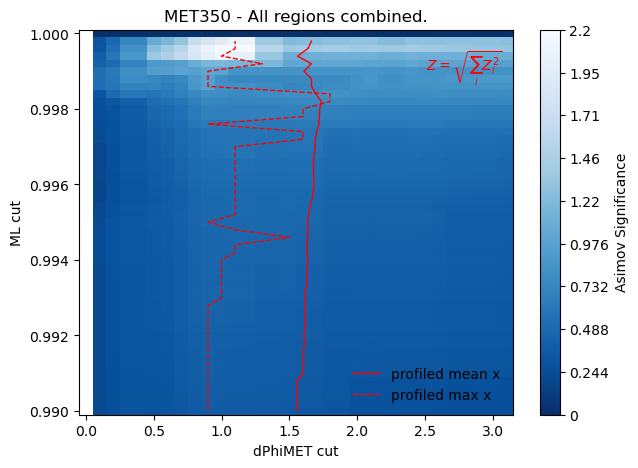

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def profile_x_mean_and_max(x, C):
    """
    For each y-bin (row of C), compute:
      - x_mean(y): weighted mean of x with weights=C[y,x] (clipped to >=0), NaNs ignored
      - x_max(y): x position of maximum weight in that row
    C shape: (Ny, Nx), x shape: (Nx,)
    """
    x = np.asarray(x, dtype=float)
    C = np.asarray(C, dtype=float)

    w = np.where(np.isfinite(C), np.clip(C, 0.0, None), np.nan)
    w0 = np.where(np.isfinite(w), w, 0.0)

    sw = w0.sum(axis=1)
    x_mean = np.divide((w0 * x[None, :]).sum(axis=1), sw,
                       out=np.full(C.shape[0], np.nan, dtype=float),
                       where=sw > 0)

    w_for_argmax = np.where(np.isfinite(w), w, -np.inf)
    imax = np.argmax(w_for_argmax, axis=1)
    row_max = np.max(w_for_argmax, axis=1)
    x_max = np.where(np.isfinite(row_max) & (row_max > 0), x[imax], np.nan)

    return x_mean, x_max


# sum Z_B over all planes robustly (aligning indices/columns)
X = None
for PLANE in PLANEs:
    Xi = tables[PLANE][key]["Z_B"]
    X = Xi.copy() if X is None else X.add(Xi**2, fill_value=0.0)

X = X.loc[0:3.1, 0.99:]
X = X.apply(np.sqrt)

fig, ax = plt.subplots(figsize=(7, 5))

x = X.index.to_numpy(dtype=float)
y = X.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)
y_edges = edges_from_centers(y)

C = X.T.to_numpy(dtype=float)  # (Ny, Nx)

absmax = np.nanmax(np.abs(C))
pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="Blues_r",
    vmin=0,
    vmax=absmax,
    shading="flat",
)

# --- profiles: single x value per y (mean solid, max dashed) ---
x_mean, x_max = profile_x_mean_and_max(x, C)

m_mean = np.isfinite(x_mean)
m_max  = np.isfinite(x_max)

ax.plot(x_mean[m_mean], y[m_mean], "r-",  lw=1.0, zorder=6, label="profiled mean x")
ax.plot(x_max[m_max],   y[m_max],  "r--", lw=1.0, zorder=6, label="profiled max x")

ax.text(
    0.80, 0.95,
    r"$Z = \sqrt{\sum_i Z_i^2}$",
    transform=ax.transAxes,
    ha="left", va="top",
    color="r"
)


ax.legend(frameon=False, loc="lower right")

cbar = fig.colorbar(pcm, ax=ax, label="Asimov Significance")
# # ensure the maximum (vmax) appears as a tick label
ticks = cbar.get_ticks()
ticks = np.unique(np.r_[ticks, absmax])   # append absmax if not already there
cbar.set_ticks(np.linspace(0,absmax,10))

cbar.update_ticks()

cbar.ax.set_yticklabels([f"{t:.3g}" for t in cbar.get_ticks()])
ax.set_xlabel("dPhiMET cut")
ax.set_ylabel("ML cut")
ax.set_title(f'{METCUT} - All regions combined.')
plt.show()


In [181]:
import ROOT

Welcome to JupyROOT 6.28/00


In [176]:
xcut = 2.0
ycut = 0.9992

sig_list = []

for ax, ZK in zip(axes, PLANEs[:]):
    sig_list.append(tables[ZK][key]['Z_B'].loc[xcut, ycut] ** 2)


print(sum(sig_list)**0.5)

0.3850133396676533


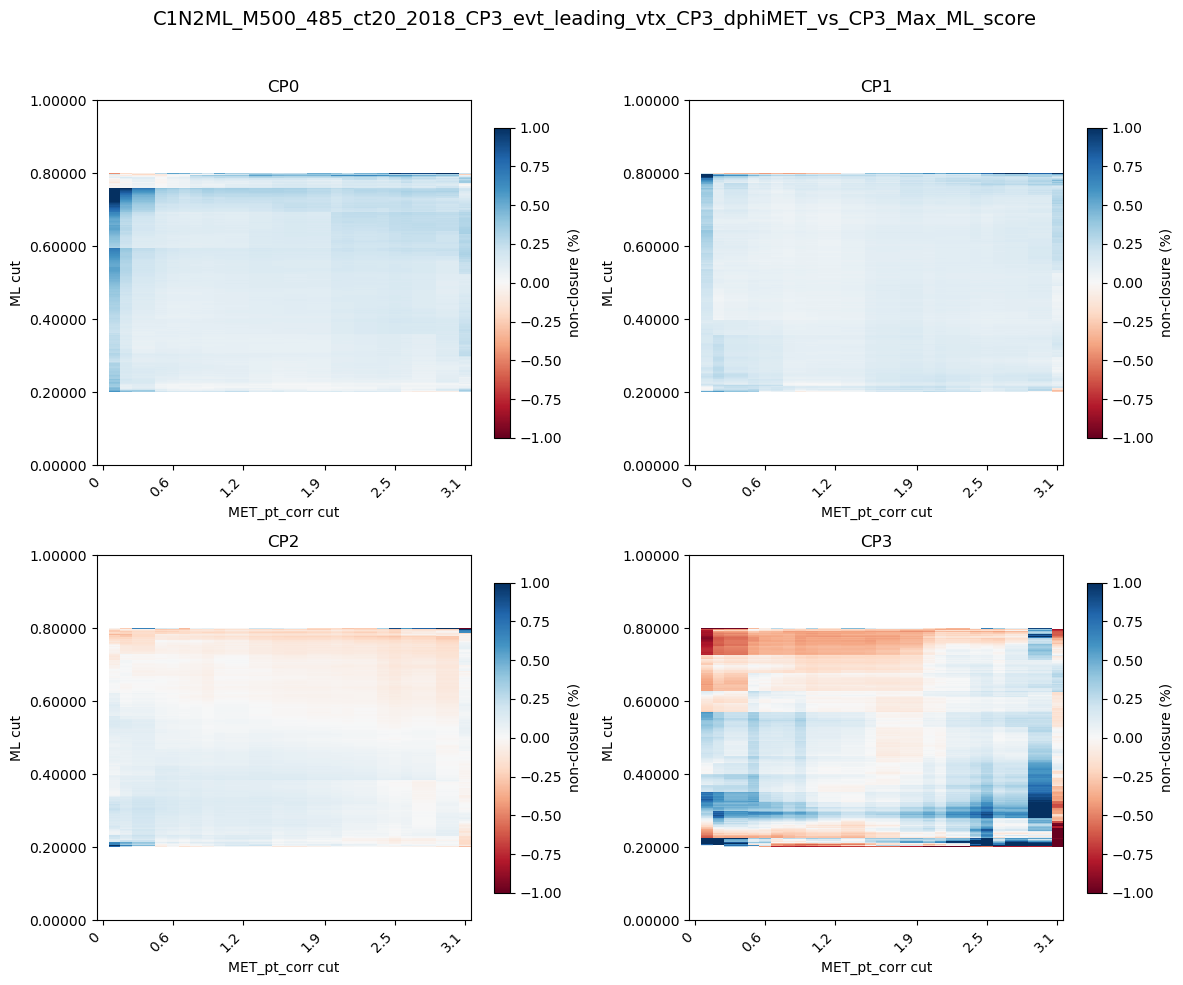

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, ZK in zip(axes, PLANEs[0:]):
    X_b = -tables[ZK][key]['delta_A'] / tables[ZK][key]['bkg_NA']
    X_b = X_b.loc[0:3.1,:]# .loc[250:, 0.998:]

    x = X_b.index.to_numpy(dtype=float)
    y = X_b.columns.to_numpy(dtype=float)

    x_edges = edges_from_centers(x)
    y_edges = edges_from_centers(y)

    C = X_b.T.to_numpy()   # (Ny, Nx)
    absmax = np.nanmax(np.abs(C))

    pcm = ax.pcolormesh(
        x_edges, y_edges, C,
        cmap="RdBu",
        vmin=-1,
        vmax=1,
        shading="flat"
    )

    ax.set_xticks(pick_ticks(x, 6))
    ax.set_yticks(pick_ticks(y, 6))

    ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()],
                       rotation=45, ha="right")
    ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

    ax.set_xlabel("MET_pt_corr cut")
    ax.set_ylabel("ML cut")
    ax.set_title(ZK)

    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.5f'))

    cbar = fig.colorbar(pcm, ax=ax, shrink=0.85)
    cbar.ax.set_ylabel("non-closure (%)")

fig.suptitle(SAMPLE, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


IndexError: index 0 is out of bounds for axis 0 with size 0

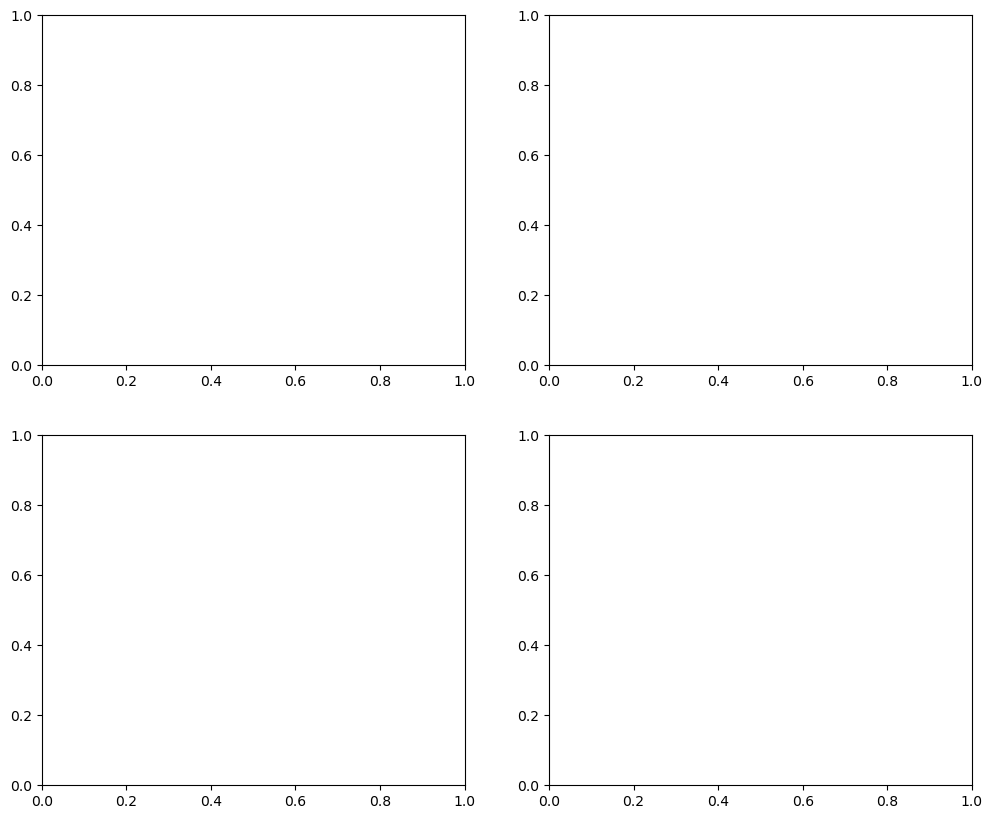

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, ZK in zip(axes, PLANEs[1:]):
    X_b = tables[ZK][key]['bkg_NA'] / tables[ZK][key]['bkg_NB']#  / tables[ZK][key]['bkg_ND']
    X_b = X_b.loc[250:, 0.998:]

    x = X_b.index.to_numpy(dtype=float)
    y = X_b.columns.to_numpy(dtype=float)

    x_edges = edges_from_centers(x)
    y_edges = edges_from_centers(y)

    C = X_b.T.to_numpy()   # (Ny, Nx)
    absmax = np.nanmax(np.abs(C))

    pcm = ax.pcolormesh(
        x_edges, y_edges, C,
        cmap="Blues_r",
        vmin=0,
        vmax=1.5,
        shading="flat"
    )

    ax.set_xticks(pick_ticks(x, 6))
    ax.set_yticks(pick_ticks(y, 6))

    ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()],
                       rotation=45, ha="right")
    ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

    ax.set_xlabel("MET_pt_corr cut")
    ax.set_ylabel("ML cut")
    ax.set_title(ZK)

    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.5f'))

    cbar = fig.colorbar(pcm, ax=ax, shrink=0.85)
    cbar.ax.set_ylabel("Transfer factor prediction")

fig.suptitle(SAMPLE, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


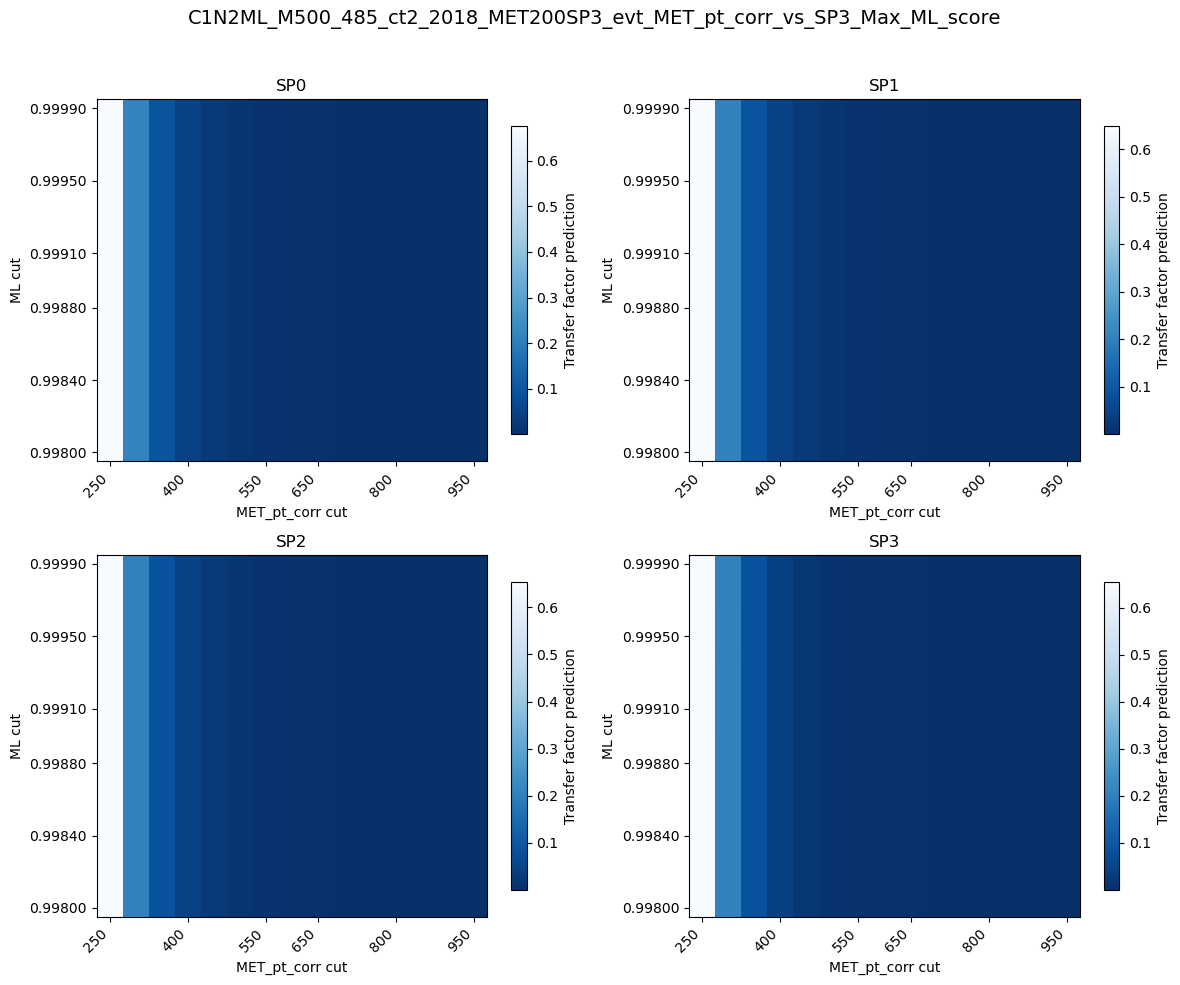

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, ZK in zip(axes, PLANEs[1:]):
    X_b = tables[ZK][key]['bkg_NC'] / tables[ZK][key]['bkg_ND']#  / tables[ZK][key]['bkg_ND']
    X_b = X_b.loc[250:, 0.998:]

    x = X_b.index.to_numpy(dtype=float)
    y = X_b.columns.to_numpy(dtype=float)

    x_edges = edges_from_centers(x)
    y_edges = edges_from_centers(y)

    C = X_b.T.to_numpy()   # (Ny, Nx)
    absmax = np.nanmax(np.abs(C))

    pcm = ax.pcolormesh(
        x_edges, y_edges, C,
        cmap="Blues_r",
        #vmin=-1,
        #vmax=1,
        shading="flat"
    )

    ax.set_xticks(pick_ticks(x, 6))
    ax.set_yticks(pick_ticks(y, 6))

    ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()],
                       rotation=45, ha="right")
    ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

    ax.set_xlabel("MET_pt_corr cut")
    ax.set_ylabel("ML cut")
    ax.set_title(ZK)

    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.5f'))

    cbar = fig.colorbar(pcm, ax=ax, shrink=0.85)
    cbar.ax.set_ylabel("Transfer factor prediction")

fig.suptitle(SAMPLE, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [21]:
def pick_ticks(vals, n=6):
    vals = np.asarray(list(vals), dtype=float)
    if len(vals) <= n:
        return vals
    idx = np.unique(np.round(np.linspace(0, len(vals)-1, n)).astype(int))
    idx[0] = 0
    idx[-1] = len(vals) - 1
    return vals[idx]

def edges_from_centers(c):
    c = np.asarray(c, dtype=float)
    d = np.diff(c)
    e = np.empty(len(c) + 1)
    e[1:-1] = c[:-1] + d / 2
    e[0]  = c[0]  - d[0] / 2
    e[-1] = c[-1] + d[-1] / 2
    return e

In [78]:


table[loCut_key]['bkg_NA'].loc[:,0.98:]

,0.9800,0.9801,0.9802,0.9803,0.9804,0.9805,0.9806,0.9807,0.9808,0.9809,...,0.9990,0.9991,0.9992,0.9993,0.9994,0.9995,0.9996,0.9997,0.9998,0.9999
50.0,2900.469189,2884.526623,2869.258257,2858.285447,2847.447008,2825.165875,2805.798218,2796.046069,2784.388613,2767.410119,...,90.996860,73.065100,63.458360,55.029387,49.478029,42.886349,26.659796,13.049457,7.368154,2.206512
100.0,2900.469189,2884.526623,2869.258257,2858.285447,2847.447008,2825.165875,2805.798218,2796.046069,2784.388613,2767.410119,...,90.996860,73.065100,63.458360,55.029387,49.478029,42.886349,26.659796,13.049457,7.368154,2.206512
150.0,2900.469189,2884.526623,2869.258257,2858.285447,2847.447008,2825.165875,2805.798218,2796.046069,2784.388613,2767.410119,...,90.996860,73.065100,63.458360,55.029387,49.478029,42.886349,26.659796,13.049457,7.368154,2.206512
200.0,1998.697039,1987.270529,1973.986497,1965.141323,1957.322487,1938.606946,1928.704143,1920.972224,1909.362321,1896.619923,...,60.846938,51.144199,42.130452,37.814415,33.231264,28.767637,21.936617,10.267465,5.262794,1.671865
250.0,762.625833,752.898532,751.044796,746.955970,742.345141,737.599068,735.726769,731.167386,727.023875,722.988128,...,21.612597,19.428659,16.239454,13.650241,12.180493,10.888561,7.911782,3.710931,2.071632,0.174339
300.0,337.470495,335.623353,335.191230,334.128174,331.320925,328.940503,327.758570,325.639406,324.662002,323.524561,...,9.567463,8.773476,7.198284,7.289294,6.813907,6.679994,4.414376,2.836772,1.432951,0.153501
350.0,149.531381,149.164300,148.413583,148.707280,147.386586,146.663678,145.919144,145.134276,144.415410,143.548257,...,2.281987,1.854478,-0.203199,-0.012968,0.743177,0.718526,-0.098109,-0.188486,-0.003641,-0.482001
400.0,72.779839,72.546149,72.356052,72.681359,71.937664,71.701406,71.007751,70.837463,70.156220,69.858221,...,2.080955,2.042818,0.532846,0.391620,0.206019,0.129185,-0.092982,-0.133594,-0.411940,-0.482001
450.0,35.182608,34.986900,34.844026,34.695850,34.562861,34.433206,33.800178,33.661292,34.008029,33.747880,...,0.724079,0.724079,0.231223,0.129466,-0.056136,-0.056136,-0.278303,-0.278303,-0.411940,-0.482001
500.0,23.093919,23.093919,22.988533,22.894225,22.792571,22.662916,22.106126,21.999516,21.898950,21.638801,...,0.664361,0.664361,0.171505,0.107515,0.107515,0.107515,0.027697,0.027697,0.000000,0.000000


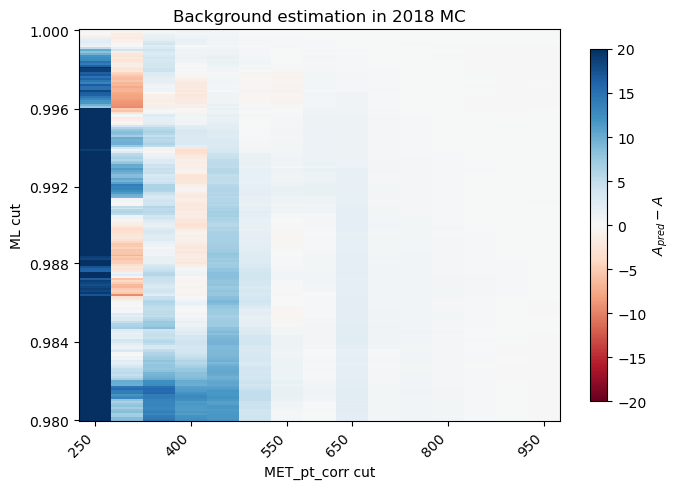

In [79]:
X_b = -table[loCut_key]['delta_A']
X_b = X_b.loc[250:, 0.98:]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)
# absmax = np.nanmax(np.abs(C))
absmax = 20

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-absmax, vmax=+absmax, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$A_{pred} - A$')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


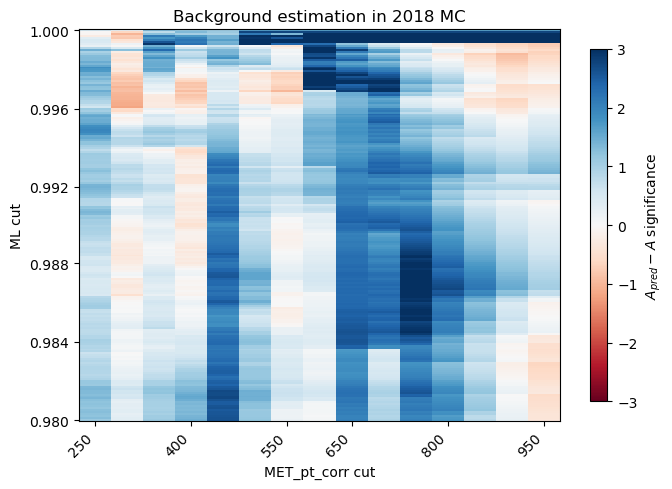

In [80]:
X_b = -table[loCut_key]['delta_A'] / table[loCut_key]['delta_A_unc']
X_b = X_b.loc[250:, 0.98:]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-3, vmax=3, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$A_{pred} - A$ significance')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


In [81]:
table[loCut_key]['delta_A_unc'].loc[:,0.98:]

,0.9800,0.9801,0.9802,0.9803,0.9804,0.9805,0.9806,0.9807,0.9808,0.9809,...,0.9990,0.9991,0.9992,0.9993,0.9994,0.9995,0.9996,0.9997,0.9998,0.9999
50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
200.0,200.808526,200.698973,200.583491,200.534617,200.492075,200.308442,199.929179,199.890567,199.808929,199.742273,...,23.561535,18.799415,18.524977,18.190636,17.853211,17.529402,6.933825,5.269441,4.200376,1.640780
250.0,50.804224,50.596241,50.517122,50.478265,50.445708,50.332624,50.266622,50.226938,50.160652,50.113747,...,5.779103,5.200779,4.978060,4.770023,4.433199,4.121747,2.963710,2.255058,1.728373,1.052898
300.0,24.652821,24.609601,24.557889,24.536969,24.510600,24.467091,24.436364,24.404603,24.378916,24.360432,...,2.948767,2.801108,2.586345,2.519841,2.312140,2.196057,1.825219,1.416137,0.998898,0.810334
350.0,13.368990,13.346209,13.297390,13.283990,13.263790,13.245920,13.214698,13.198875,13.167365,13.159563,...,1.716561,1.654721,1.374100,1.271065,1.049047,1.035366,0.809076,0.785731,0.569066,0.487607
400.0,8.535555,8.532891,8.504818,8.485609,8.470024,8.465647,8.449650,8.448710,8.403967,8.402342,...,1.049395,1.031605,0.609582,0.600367,0.582952,0.575381,0.526265,0.516359,0.491035,0.483433
450.0,4.503870,4.501153,4.499458,4.497108,4.496285,4.493534,4.466232,4.465339,4.437428,4.435673,...,0.745743,0.738640,0.548709,0.542544,0.527086,0.525450,0.503015,0.500456,0.486554,0.482425
500.0,3.473189,3.472750,3.471725,3.469236,3.468580,3.466787,3.432663,3.431944,3.431025,3.429190,...,0.512836,0.509387,0.126617,0.107390,0.104684,0.101895,0.053292,0.044517,0.025202,0.012542


In [82]:
table[loCut_key]['delta_A'].loc[:,0.98:]

,0.9800,0.9801,0.9802,0.9803,0.9804,0.9805,0.9806,0.9807,0.9808,0.9809,...,0.9990,0.9991,0.9992,0.9993,0.9994,0.9995,0.9996,0.9997,0.9998,0.9999
50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
200.0,-146.931472,-147.616603,-156.227920,-160.032056,-160.669546,-170.958635,-158.269509,-161.210720,-172.771392,-175.448691,...,-10.864254,-0.993007,-8.597391,-3.130326,-5.410893,-4.812993,10.703242,3.650789,0.255371,0.400254
250.0,-57.038928,-64.423977,-61.116062,-62.573407,-64.808609,-62.820522,-57.958672,-60.540894,-61.810191,-60.878507,...,-4.980491,-1.128185,-1.857878,-2.208955,-2.114355,-1.375016,0.726459,0.131854,0.041689,-0.604514
300.0,-8.661442,-8.604697,-7.024693,-6.747992,-8.479917,-8.171126,-6.890366,-7.984466,-7.517108,-6.510034,...,-1.428293,0.092113,-0.398630,0.842977,1.053014,1.791143,1.410617,1.457772,0.631522,-0.123721
350.0,-14.741420,-14.175338,-14.058517,-13.086836,-13.843254,-13.275835,-12.906392,-13.157127,-13.223173,-13.127786,...,-3.013577,-2.396136,-4.003407,-3.298585,-2.165819,-1.798452,-1.695271,-0.978631,-0.443641,-0.642471
400.0,-12.406620,-12.165762,-11.900190,-11.230938,-11.672906,-11.242794,-11.374616,-11.255637,-11.608080,-11.402522,...,-0.595686,-0.095102,-1.361498,-1.253213,-1.277284,-1.157983,-0.898339,-0.530442,-0.646146,-0.562933
450.0,-11.772908,-11.710220,-11.604655,-11.575286,-11.532613,-11.298021,-11.625776,-11.607026,-11.060715,-11.046839,...,-0.753395,-0.459869,-0.803607,-0.769071,-0.866861,-0.758966,-0.719191,-0.496429,-0.539272,-0.526002
500.0,-4.144270,-3.992533,-3.954180,-3.945466,-3.945485,-3.865030,-4.245760,-4.261141,-4.252257,-4.354672,...,-0.190082,-0.020444,-0.427146,-0.412007,-0.359490,-0.297133,-0.224214,-0.095471,-0.069693,-0.020870


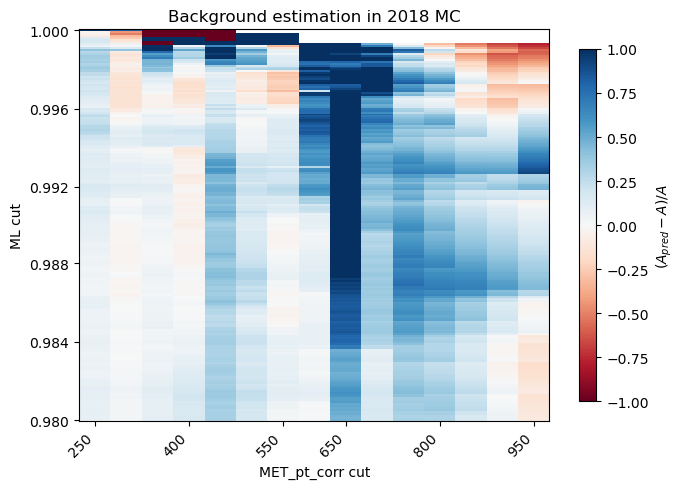

In [83]:
X_b = -table[loCut_key]['delta_A'] / table[loCut_key]['bkg_NA']
X_b = X_b.loc[250:, 0.98:]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-1, vmax=+1, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$(A_{pred} - A) / A$')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


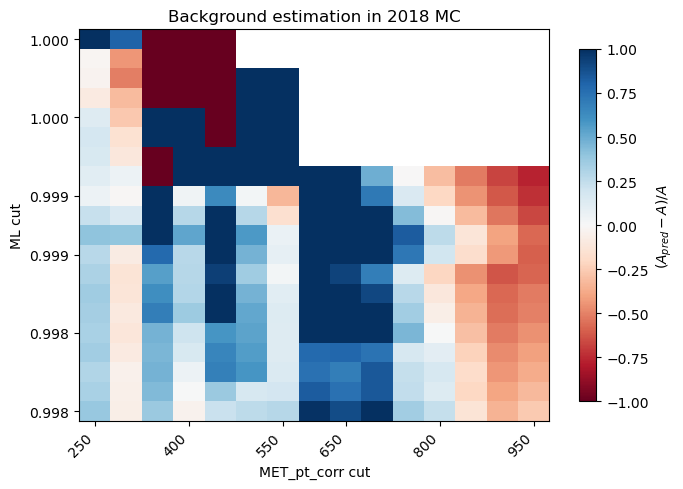

In [84]:
X_b = -table[loCut_key]['delta_A'] / table[loCut_key]['bkg_NA']
X_b = X_b.loc[250:, 0.998:]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-1, vmax=+1, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$(A_{pred} - A) / A$')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


In [85]:
table[loCut_key]['bkg_NA'].loc[100:600,0.999:]

,0.9990,0.9991,0.9992,0.9993,0.9994,0.9995,0.9996,0.9997,0.9998,0.9999
100.0,90.996860,73.065100,63.458360,55.029387,49.478029,42.886349,26.659796,13.049457,7.368154,2.206512
150.0,90.996860,73.065100,63.458360,55.029387,49.478029,42.886349,26.659796,13.049457,7.368154,2.206512
200.0,60.846938,51.144199,42.130452,37.814415,33.231264,28.767637,21.936617,10.267465,5.262794,1.671865
250.0,21.612597,19.428659,16.239454,13.650241,12.180493,10.888561,7.911782,3.710931,2.071632,0.174339
300.0,9.567463,8.773476,7.198284,7.289294,6.813907,6.679994,4.414376,2.836772,1.432951,0.153501
350.0,2.281987,1.854478,-0.203199,-0.012968,0.743177,0.718526,-0.098109,-0.188486,-0.003641,-0.482001
400.0,2.080955,2.042818,0.532846,0.391620,0.206019,0.129185,-0.092982,-0.133594,-0.411940,-0.482001
450.0,0.724079,0.724079,0.231223,0.129466,-0.056136,-0.056136,-0.278303,-0.278303,-0.411940,-0.482001
500.0,0.664361,0.664361,0.171505,0.107515,0.107515,0.107515,0.027697,0.027697,0.000000,0.000000
550.0,0.625782,0.625782,0.132926,0.068936,0.068936,0.068936,0.027697,0.027697,0.000000,0.000000


In [86]:
table[loCut_key]['bkg_NA_unc'].loc[100:600,0.999:]

,0.9990,0.9991,0.9992,0.9993,0.9994,0.9995,0.9996,0.9997,0.9998,0.9999
100.0,11.585437,9.749173,9.428517,9.189548,8.836208,8.466902,4.807792,3.682880,2.663672,1.325829
150.0,11.585437,9.749173,9.428517,9.189548,8.836208,8.466902,4.807792,3.682880,2.663672,1.325829
200.0,6.629623,6.294720,5.861117,5.618086,5.141440,4.596111,4.213874,3.242605,2.197872,1.247886
250.0,4.000071,3.913867,3.704666,3.480995,3.095614,2.750046,2.512650,1.903902,1.509892,0.998388
300.0,2.521775,2.494782,2.271621,2.213064,1.998504,1.892094,1.721537,1.338179,0.940497,0.797614
350.0,1.573531,1.551544,1.255549,1.148460,0.908241,0.905112,0.757754,0.755685,0.547375,0.482001
400.0,0.990014,0.989315,0.539545,0.532945,0.518851,0.515998,0.506169,0.504537,0.484661,0.482001
450.0,0.721239,0.721239,0.526572,0.521304,0.506886,0.506886,0.496877,0.496877,0.484661,0.482001
500.0,0.500958,0.500958,0.089726,0.062898,0.062898,0.062898,0.027697,0.027697,0.000000,0.000000
550.0,0.499470,0.499470,0.081009,0.049677,0.049677,0.049677,0.027697,0.027697,0.000000,0.000000


In [87]:
table[loCut_key]['sig_NA'].loc[100:600,0.999:]

,0.9990,0.9991,0.9992,0.9993,0.9994,0.9995,0.9996,0.9997,0.9998,0.9999
100.0,14.242738,14.063106,13.858912,13.603921,13.128233,12.730064,12.185656,11.407852,10.348246,8.097553
150.0,14.242738,14.063106,13.858912,13.603921,13.128233,12.730064,12.185656,11.407852,10.348246,8.097553
200.0,13.559450,13.379818,13.175625,12.920634,12.444945,12.046776,11.539811,10.781526,9.721920,7.566753
250.0,10.782853,10.647961,10.465147,10.231613,9.918059,9.648343,9.320309,8.732099,7.786251,6.222243
300.0,8.169084,8.056580,7.941695,7.755617,7.528094,7.369987,7.156604,6.748827,6.023741,4.846996
350.0,5.799692,5.736874,5.645118,5.505110,5.347509,5.256657,5.089202,4.819145,4.319677,3.370610
400.0,4.409700,4.367101,4.321635,4.228195,4.070594,4.002363,3.834908,3.700032,3.315265,2.624701
450.0,3.483618,3.441019,3.395553,3.302112,3.167478,3.099247,2.980949,2.869002,2.575418,2.047220
500.0,2.660815,2.618216,2.595792,2.502351,2.367717,2.322026,2.228192,2.116245,1.845652,1.431176
550.0,2.126205,2.083607,2.061182,1.967741,1.856031,1.833388,1.787837,1.675890,1.542268,1.219435


In [88]:
table[loCut_key]['Z_A'].loc[100:600,1:0.999:-1].T

,100.0,150.0,200.0,250.0,300.0,350.0,400.0,450.0,500.0,550.0,600.0
0.9999,2.474127,2.474127,2.405372,1.955782,1.984327,2.070334,1.746289,1.465866,1.126659,0.997223,0.819879
0.9998,1.958544,1.958544,2.127855,2.227930,2.368966,2.327130,2.047504,1.723493,1.360159,1.191622,0.915178
0.9997,1.640956,1.640956,1.746261,2.153447,2.137075,2.051815,2.193101,1.856564,1.501044,1.267364,0.986486
0.9996,1.234761,1.234761,1.330647,1.823331,1.907926,2.118396,2.241886,1.905671,1.557070,1.328965,1.056233
0.9995,0.857348,0.857348,1.194994,1.676018,1.735148,2.062165,2.283584,1.943916,1.603101,1.353576,1.070129
0.9994,0.813646,0.813646,1.112767,1.590842,1.724519,2.092735,2.302469,1.972697,1.625221,1.365716,1.083875
0.9993,0.787574,0.787574,1.053065,1.511411,1.675530,1.624294,2.327702,2.000943,1.689336,1.424731,1.138718
0.9992,0.736781,0.736781,1.000904,1.425669,1.696581,1.530891,2.360856,2.028320,1.732940,1.473022,1.180440
0.9991,0.681897,0.681897,0.893015,1.330949,1.579696,1.746600,1.789253,1.784118,1.737195,1.474450,1.193392
0.9990,0.577077,0.577077,0.802589,1.280170,1.555267,1.764375,1.798260,1.799361,1.757706,1.496785,1.217794


In [89]:
-table[loCut_key]['delta_A'] / table[loCut_key]['bkg_NA']

,0.0001,0.0002,0.0003,0.0004,0.0005,0.0006,0.0007,0.0008,0.0009,0.0010,...,0.9990,0.9991,0.9992,0.9993,0.9994,0.9995,0.9996,0.9997,0.9998,0.9999
50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
200.0,-0.097191,-0.095825,-0.064971,-0.017776,-0.020029,-0.007971,-0.007540,-0.007114,0.001081,0.005977,...,0.178551,0.019416,0.204066,0.082781,0.162825,0.167306,-0.487917,-0.355569,-0.048524,-0.239406
250.0,-0.130677,0.013142,0.024070,0.011531,0.004763,0.027944,0.010677,0.016682,0.022446,0.015099,...,0.230444,0.058068,0.114405,0.161825,0.173585,0.126281,-0.091820,-0.035531,-0.020124,3.467456
300.0,-0.057651,-0.025725,0.009153,0.017263,0.014659,0.028294,0.025249,0.014677,0.014632,0.018169,...,0.149287,-0.010499,0.055378,-0.115646,-0.154539,-0.268135,-0.319551,-0.513884,-0.440714,0.805994
350.0,-0.065672,0.037557,0.024056,0.011794,0.017483,0.004259,0.014942,0.002842,0.008464,0.013999,...,1.320593,1.292081,-19.701908,-254.362001,2.914270,2.502973,-17.279477,-5.192063,-121.833485,-1.332924
400.0,-0.061247,0.086353,0.060255,0.051171,0.049609,0.056415,0.051064,0.037297,0.035747,0.043028,...,0.286256,0.046554,2.555145,3.200070,6.199843,8.963766,-9.661388,-3.970558,-1.568542,-1.167909
450.0,-0.231177,-0.007976,-0.042795,-0.038052,-0.017898,-0.007951,-0.010075,-0.017509,-0.016398,0.008803,...,1.040486,0.635109,3.475469,5.940350,-15.442129,-13.520109,-2.584199,-1.783770,-1.309103,-1.091288
500.0,-0.188028,0.003467,0.025119,0.040861,0.036211,0.042606,0.030009,0.005364,0.012196,0.013240,...,0.286112,0.030773,2.490579,3.832090,3.343630,2.763645,8.095138,3.446951,inf,inf


In [90]:
table[loCut_key]['bkg_NA'].loc[:,0.98:]

,0.9800,0.9801,0.9802,0.9803,0.9804,0.9805,0.9806,0.9807,0.9808,0.9809,...,0.9990,0.9991,0.9992,0.9993,0.9994,0.9995,0.9996,0.9997,0.9998,0.9999
50.0,2900.469189,2884.526623,2869.258257,2858.285447,2847.447008,2825.165875,2805.798218,2796.046069,2784.388613,2767.410119,...,90.996860,73.065100,63.458360,55.029387,49.478029,42.886349,26.659796,13.049457,7.368154,2.206512
100.0,2900.469189,2884.526623,2869.258257,2858.285447,2847.447008,2825.165875,2805.798218,2796.046069,2784.388613,2767.410119,...,90.996860,73.065100,63.458360,55.029387,49.478029,42.886349,26.659796,13.049457,7.368154,2.206512
150.0,2900.469189,2884.526623,2869.258257,2858.285447,2847.447008,2825.165875,2805.798218,2796.046069,2784.388613,2767.410119,...,90.996860,73.065100,63.458360,55.029387,49.478029,42.886349,26.659796,13.049457,7.368154,2.206512
200.0,1998.697039,1987.270529,1973.986497,1965.141323,1957.322487,1938.606946,1928.704143,1920.972224,1909.362321,1896.619923,...,60.846938,51.144199,42.130452,37.814415,33.231264,28.767637,21.936617,10.267465,5.262794,1.671865
250.0,762.625833,752.898532,751.044796,746.955970,742.345141,737.599068,735.726769,731.167386,727.023875,722.988128,...,21.612597,19.428659,16.239454,13.650241,12.180493,10.888561,7.911782,3.710931,2.071632,0.174339
300.0,337.470495,335.623353,335.191230,334.128174,331.320925,328.940503,327.758570,325.639406,324.662002,323.524561,...,9.567463,8.773476,7.198284,7.289294,6.813907,6.679994,4.414376,2.836772,1.432951,0.153501
350.0,149.531381,149.164300,148.413583,148.707280,147.386586,146.663678,145.919144,145.134276,144.415410,143.548257,...,2.281987,1.854478,-0.203199,-0.012968,0.743177,0.718526,-0.098109,-0.188486,-0.003641,-0.482001
400.0,72.779839,72.546149,72.356052,72.681359,71.937664,71.701406,71.007751,70.837463,70.156220,69.858221,...,2.080955,2.042818,0.532846,0.391620,0.206019,0.129185,-0.092982,-0.133594,-0.411940,-0.482001
450.0,35.182608,34.986900,34.844026,34.695850,34.562861,34.433206,33.800178,33.661292,34.008029,33.747880,...,0.724079,0.724079,0.231223,0.129466,-0.056136,-0.056136,-0.278303,-0.278303,-0.411940,-0.482001
500.0,23.093919,23.093919,22.988533,22.894225,22.792571,22.662916,22.106126,21.999516,21.898950,21.638801,...,0.664361,0.664361,0.171505,0.107515,0.107515,0.107515,0.027697,0.027697,0.000000,0.000000


In [91]:
table[loCut_key]['noncl'].loc[250:,0.98:] - table[loCut_key]['noncl_unc'].loc[250:,0.98:]

,0.9800,0.9801,0.9802,0.9803,0.9804,0.9805,0.9806,0.9807,0.9808,0.9809,...,0.9990,0.9991,0.9992,0.9993,0.9994,0.9995,0.9996,0.9997,0.9998,0.9999
250.0,0.006360,0.016293,0.012142,0.014157,0.017216,0.014839,0.008520,0.012063,0.013917,0.012797,...,-0.068064,-0.218528,-0.212025,-0.218784,-0.222440,-0.274243,-0.258394,-0.556838,-0.801399,-22.188103
300.0,-0.048598,-0.048902,-0.053299,-0.054196,-0.049605,-0.050733,-0.054544,-0.051609,-0.053057,-0.056151,...,-0.193180,-0.306115,-0.319365,-0.199656,-0.146474,0.002013,0.020737,0.232340,0.004931,-8.624383
350.0,0.002435,-0.000942,-0.001351,-0.007321,-0.002514,-0.006033,-0.008219,-0.006571,-0.005972,-0.006606,...,-0.307550,-0.650500,0.000000,0.000000,-1.921257,-1.964775,0.000000,0.000000,0.000000,0.000000
400.0,0.036081,0.033196,0.030394,0.022363,0.028205,0.022913,0.024904,0.023430,0.028751,0.026187,...,-0.348119,-0.480097,-1.083858,-2.559103,-11.978535,-30.882879,0.000000,0.000000,0.000000,0.000000
450.0,0.170091,0.169333,0.167230,0.167121,0.166551,0.161068,0.173062,0.173151,0.158661,0.159297,...,-1.008793,-1.008394,-6.738503,-22.029647,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
500.0,0.004429,-0.001218,-0.002725,-0.003035,-0.003124,-0.006251,0.009571,0.010120,0.009735,0.013655,...,-0.697639,-0.758790,0.591571,0.891610,0.686026,0.439043,-1.147354,-1.174589,0.000000,0.000000
550.0,-0.123060,-0.127977,-0.131131,-0.130023,-0.130157,-0.132840,-0.113290,-0.111220,-0.114998,-0.112013,...,-0.512446,-0.212988,0.028009,0.201399,0.068764,-0.091022,-1.090283,-1.106928,0.000000,0.000000
600.0,-0.154417,-0.159146,-0.161376,-0.157829,-0.156250,-0.156569,-0.162453,-0.160467,-0.164026,-0.157083,...,-1.041821,-1.036847,-1.039590,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
650.0,0.137363,0.131027,0.131181,0.146542,0.142131,0.150794,0.142798,0.152554,0.147687,0.168758,...,-1.026714,-1.023533,-1.025276,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
700.0,-0.037225,-0.042596,-0.047134,-0.041009,-0.044704,-0.038856,-0.045544,-0.048914,-0.052936,-0.049806,...,-1.017488,-1.015400,-1.016530,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


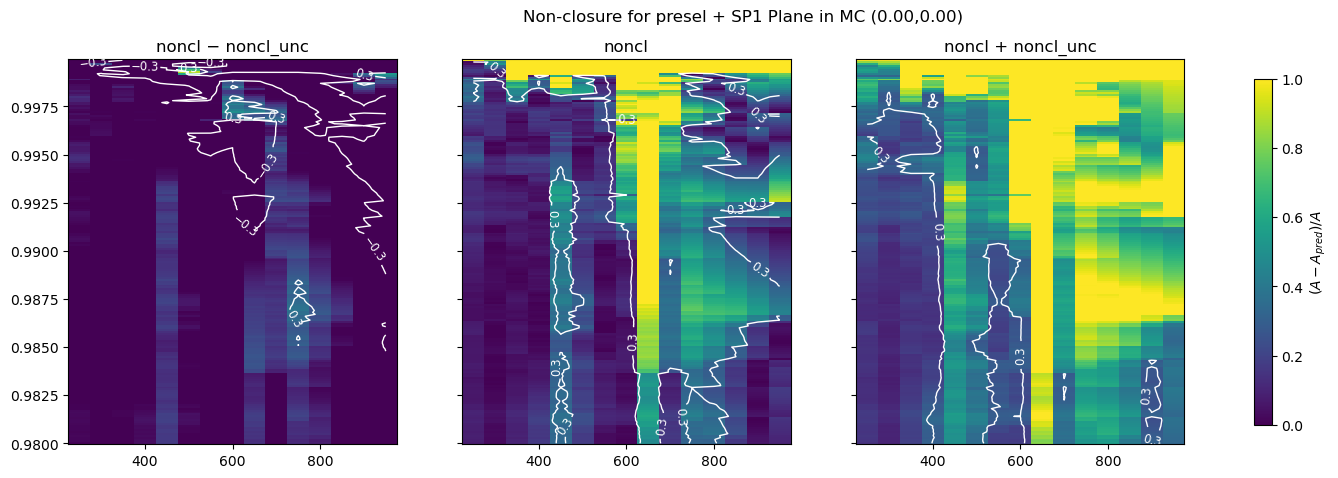

In [92]:
def plot_updown(Z_noncl_minus, Z_noncl, Z_noncl_plus, suptitle):
    # Common contour levels
    base_levels = [-0.30, 0.30]
    global_max = np.nanmax([
        np.nanmax(Z_noncl_minus.values),
        np.nanmax(Z_noncl.values),
        np.nanmax(Z_noncl_plus.values)
    ])
    levels = [lv for lv in base_levels if lv <= global_max]

    # Shared color scale
    vmin =  0
    vmax =  1

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    fig.suptitle(suptitle)

    # ---------------- LEFT: noncl - noncl_unc ----------------
    ax = axes[0]
    ax.set_title("noncl − noncl_unc")
    pcm0 = ax.pcolormesh(
        Z_noncl_minus.index, Z_noncl_minus.columns, Z_noncl_minus.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont0 = ax.contour(
            Z_noncl_minus.index, Z_noncl_minus.columns, Z_noncl_minus.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont0, fontsize="smaller")
    # ax.set_xlim(0., 0.5)
    # ax.set_ylim(0., 0.5)
    # ax.set_xlabel("leading_vtx_ML1 cut")
    # ax.set_ylabel("leading_vtx_ML2 cut")

    # ---------------- MIDDLE: noncl ----------------
    ax = axes[1]
    ax.set_title("noncl")
    pcm1 = ax.pcolormesh(
        Z_noncl.index, Z_noncl.columns, Z_noncl.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont1 = ax.contour(
            Z_noncl.index, Z_noncl.columns, Z_noncl.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont1, fontsize="smaller")
    # ax.set_xlim(0., 0.5)
    # ax.set_ylim(0., 0.5)
    # ax.set_xlabel("leading_vtx_ML1 cut")

    # ---------------- RIGHT: noncl + noncl_unc ----------------
    ax = axes[2]
    ax.set_title("noncl + noncl_unc")
    pcm2 = ax.pcolormesh(
        Z_noncl_plus.index, Z_noncl_plus.columns, Z_noncl_plus.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont2 = ax.contour(
            Z_noncl_plus.index, Z_noncl_plus.columns, Z_noncl_plus.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont2, fontsize="smaller")
    # ax.set_xlim(0., 0.5)
    # ax.set_ylim(0., 0.5)
    # ax.set_xlabel("leading_vtx_ML1 cut")

    # Shared colorbar
    cbar = fig.colorbar(pcm2, ax=axes.ravel().tolist(), shrink=0.90)
    cbar.ax.set_ylabel(r"$(A - A_{pred}) / A$")

    plt.show()

key = loCut_key
noncl          =  table[key]['noncl'].loc[250:,0.98:]
noncl_plus1s   =  table[key]['noncl'].loc[250:,0.98:] + table[key]['noncl_unc'].loc[250:,0.98:]
noncl_minus1s  =  table[key]['noncl'].loc[250:,0.98:] - table[key]['noncl_unc'].loc[250:,0.98:]
plot_updown(noncl_minus1s, noncl, noncl_plus1s, suptitle=f"Non-closure for presel + SP1 Plane in MC ({key})")

### Overall Picture

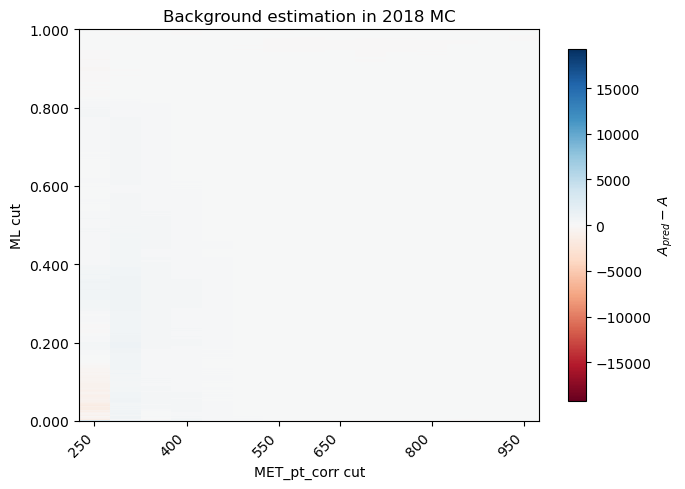

In [93]:
key = loCut_key
X_b = -table[key]['delta_A']
X_b = X_b.loc[250:,:]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)
absmax = np.nanmax(np.abs(C))

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-absmax, vmax=+absmax, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$A_{pred} - A$')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


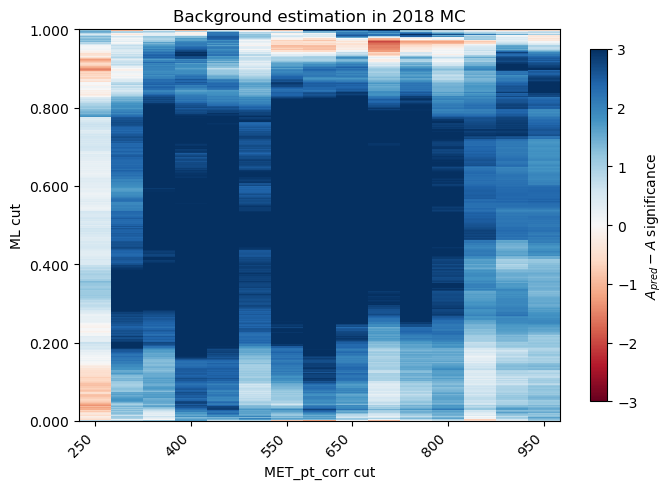

In [94]:
X_b = -table[loCut_key]['delta_A'] / table[loCut_key]['delta_A_unc']
X_b = X_b.loc[250:, :]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-3, vmax=3, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$A_{pred} - A$ significance')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


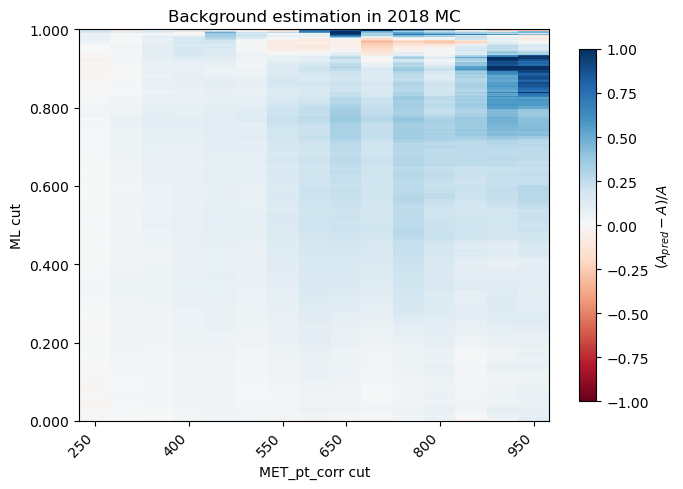

In [95]:
key = loCut_key
X_b = -table[key]['delta_A'] / table[key]['bkg_NA']
X_b = X_b.loc[250:, :]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-1, vmax=+1, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$(A_{pred} - A) / A$')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


### Significance

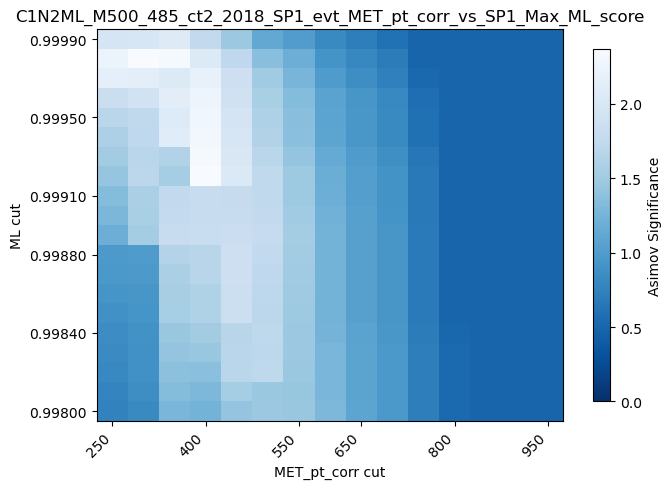

In [96]:
import matplotlib.ticker as mtick



key = loCut_key
X_b = table[key]['Z_A']
X_b = X_b.loc[250:, 0.998:]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)
absmax = np.nanmax(np.abs(C))

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="Blues_r", vmin=0, vmax=+absmax, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'Asimov Significance')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title(SAMPLE)

ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.5f'))

fig.tight_layout()
plt.show()


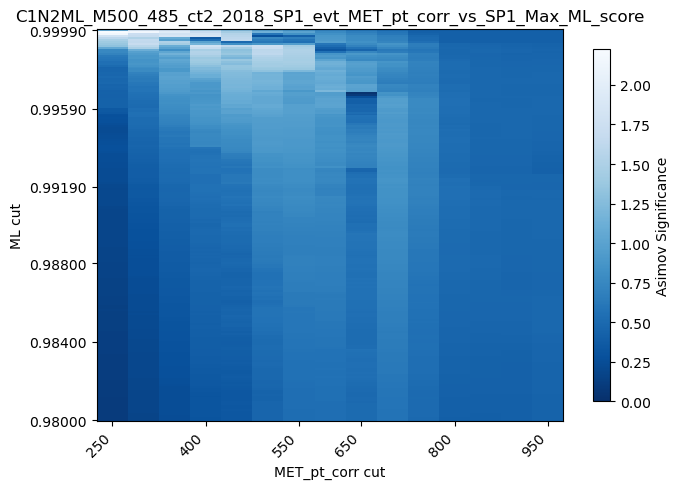

In [97]:
X_b = table[loCut_key]['Z_noncl_A']
X_b = X_b.loc[250:, 0.98:]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)
absmax = np.nanmax(np.abs(C))

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="Blues_r", vmin=0, vmax=+absmax, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'Asimov Significance')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title(SAMPLE)

ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.5f'))

fig.tight_layout()
plt.show()


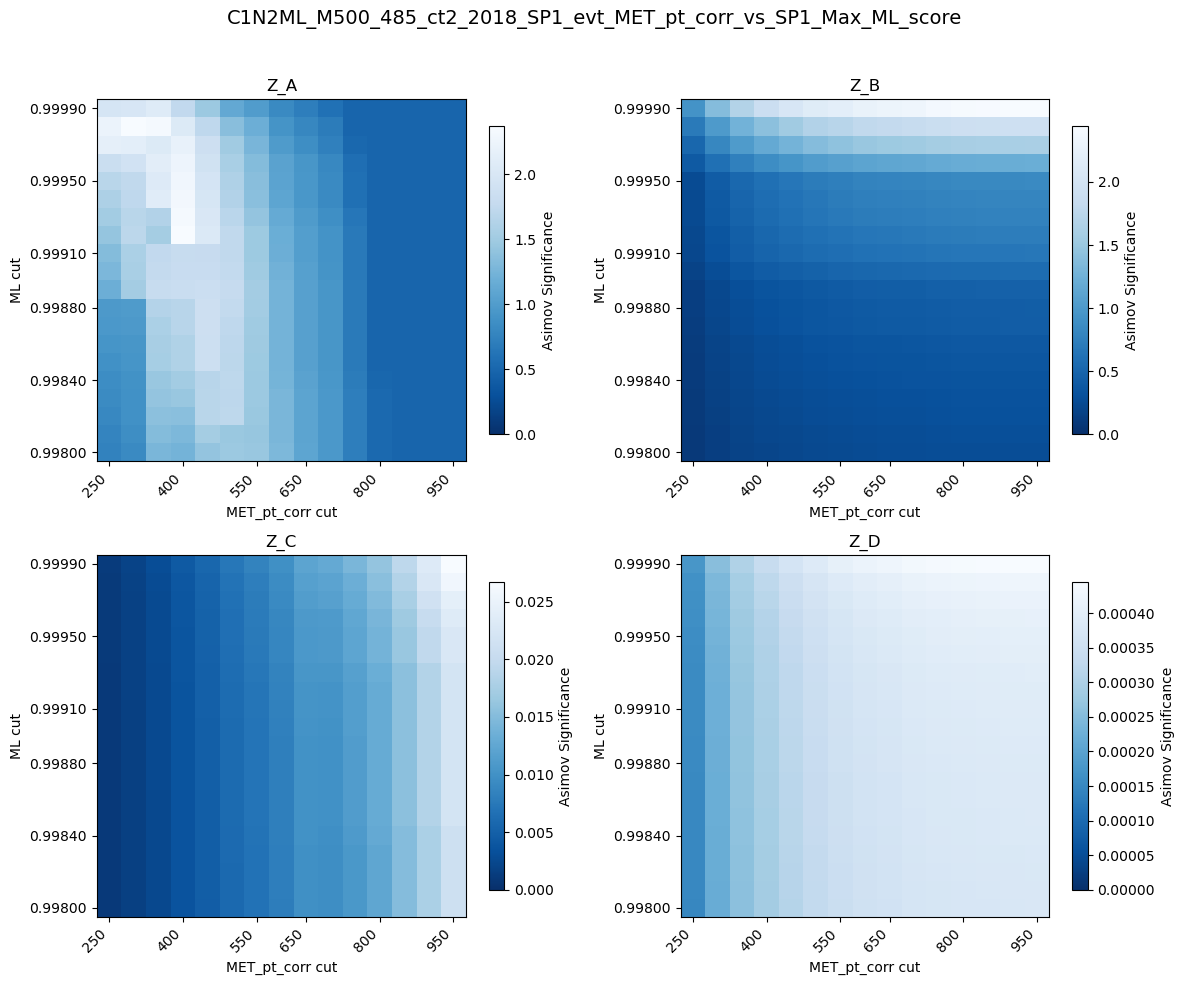

In [98]:
import matplotlib.ticker as mtick

Z_KEYS = ["Z_A", "Z_B", "Z_C", "Z_D"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, ZK in zip(axes, Z_KEYS):

    X_b = table[key][ZK]
    X_b = X_b.loc[250:, 0.998:]

    x = X_b.index.to_numpy(dtype=float)
    y = X_b.columns.to_numpy(dtype=float)

    x_edges = edges_from_centers(x)
    y_edges = edges_from_centers(y)

    C = X_b.T.to_numpy()   # (Ny, Nx)
    absmax = np.nanmax(np.abs(C))

    pcm = ax.pcolormesh(
        x_edges, y_edges, C,
        cmap="Blues_r",
        vmin=0,
        vmax=absmax,
        shading="flat"
    )

    ax.set_xticks(pick_ticks(x, 6))
    ax.set_yticks(pick_ticks(y, 6))

    ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()],
                       rotation=45, ha="right")
    ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

    ax.set_xlabel("MET_pt_corr cut")
    ax.set_ylabel("ML cut")
    ax.set_title(ZK)

    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.5f'))

    cbar = fig.colorbar(pcm, ax=ax, shrink=0.85)
    cbar.ax.set_ylabel("Asimov Significance")

fig.suptitle(SAMPLE, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [107]:
table[key]['Z_A'].loc[250:, 0.999:]

,0.9990,0.9991,0.9992,0.9993,0.9994,0.9995,0.9996,0.9997,0.9998,0.9999
250.0,1.280170,1.330949,1.425669,1.511411,1.590842,1.676018,1.823331,2.153447,2.227930,1.955782
300.0,1.555267,1.579696,1.696581,1.675530,1.724519,1.735148,1.907926,2.137075,2.368966,1.984327
350.0,1.764375,1.746600,1.530891,1.624294,2.092735,2.062165,2.118396,2.051815,2.327130,2.070334
400.0,1.798260,1.789253,2.360856,2.327702,2.302469,2.283584,2.241886,2.193101,2.047504,1.746289
450.0,1.799361,1.784118,2.028320,2.000943,1.972697,1.943916,1.905671,1.856564,1.723493,1.465866
500.0,1.757706,1.737195,1.732940,1.689336,1.625221,1.603101,1.557070,1.501044,1.360159,1.126659
550.0,1.496785,1.474450,1.473022,1.424731,1.365716,1.353576,1.328965,1.267364,1.191622,0.997223
600.0,1.217794,1.193392,1.180440,1.138718,1.083875,1.070129,1.056233,0.986486,0.915178,0.819879
650.0,1.029685,1.015345,1.015345,0.984841,0.940812,0.940812,0.926030,0.851664,0.791025,0.706004
700.0,0.913673,0.898505,0.898505,0.866202,0.819485,0.819485,0.803775,0.724534,0.691063,0.601233


In [ ]:
x_max, y_max = table[key]['Z_A'].loc[250:, 0.999:].stack().idxmax()
print('Cut at x: ', x_max)
print('Cut at y: ', y_max)
print()

print('B signif.: \t', f"{table[key]['Z_B'].loc[x_max, y_max]:.3f}")
print('B sig yield: \t',    f"{table[key]['sig_NB'].loc[x_max, y_max]:.3f}")
print('B bkg yield: \t',    f"{table[key]['bkg_NB'].loc[x_max, y_max]:.3f}")

Cut at x:  300.0
Cut at y:  0.9998

B signif.: 	 1.006
B sig yield: 	 4.325
B bkg yield: 	 5.935


In [118]:
x_cut, y_cut = 400, 0.9992000000000001
print('Cut at x: ', x_cut)
print('Cut at y: ', y_cut)
print()

print('B signif.: \t', f"{table[key]['Z_B'].loc[x_cut, y_cut]:.3f}")
print('B sig yield: \t',    f"{table[key]['sig_NB'].loc[x_cut, y_cut]:.3f}")
print('B bkg yield: \t',    f"{table[key]['bkg_NB'].loc[x_cut, y_cut]:.3f}")

Cut at x:  400
Cut at y:  0.9992000000000001

B signif.: 	 0.519
B sig yield: 	 9.537
B bkg yield: 	 62.926


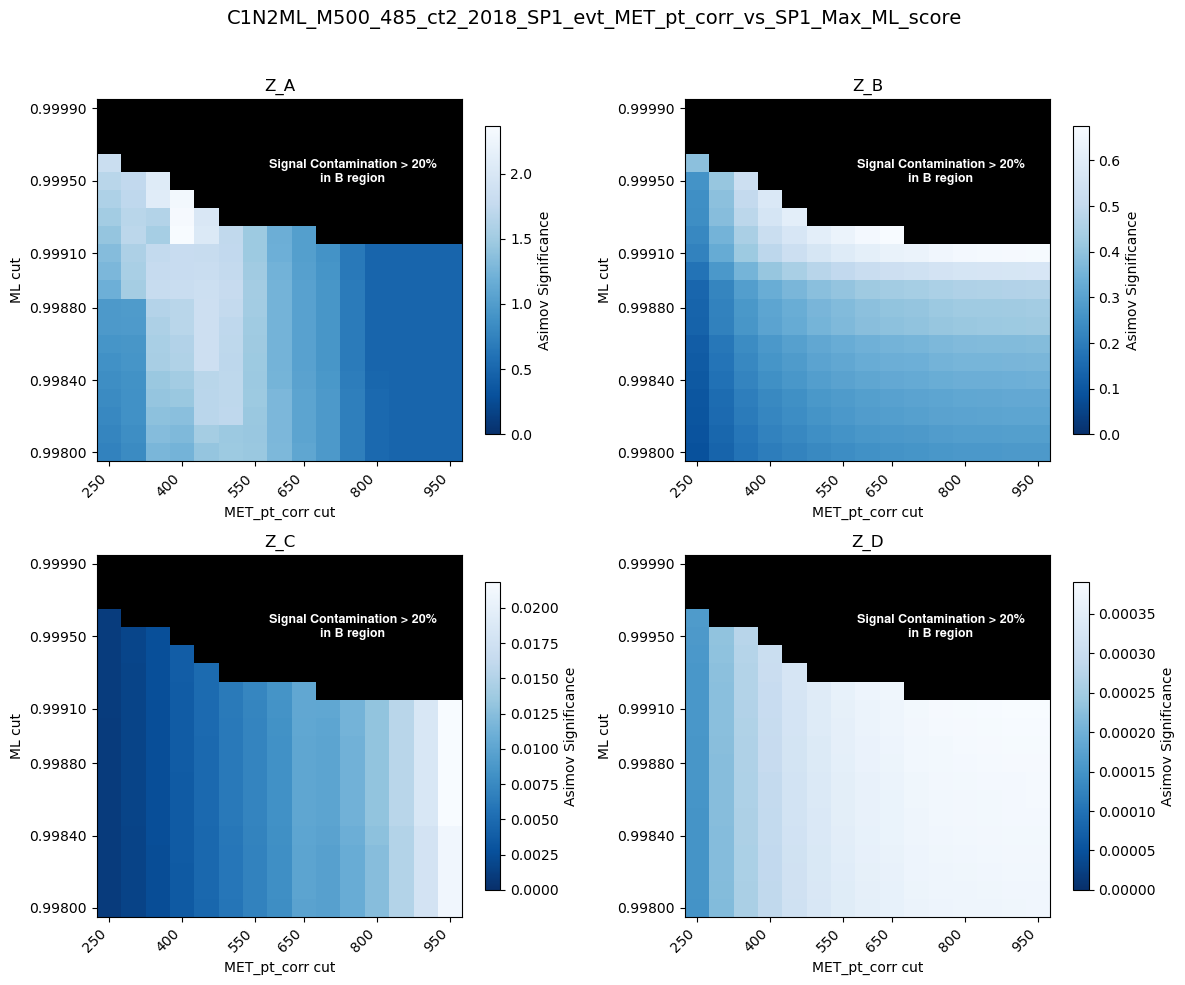

In [100]:
sig_contamination_upper_limit = 0.20

blinding_mask = (table[key]['sig_NB'] / table[key]['bkg_NB'] < sig_contamination_upper_limit)
import matplotlib.ticker as mtick

Z_KEYS = ["Z_A", "Z_B", "Z_C", "Z_D"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, ZK in zip(axes, Z_KEYS):

    X_b = table[key][ZK][blinding_mask]
    X_b = X_b.loc[250:, 0.998:]

    x = X_b.index.to_numpy(dtype=float)
    y = X_b.columns.to_numpy(dtype=float)

    x_edges = edges_from_centers(x)
    y_edges = edges_from_centers(y)

    C = X_b.T.to_numpy()
    C = np.ma.masked_invalid(C)

    absmax = np.nanmax(np.abs(C))

    cmap = plt.cm.Blues_r.copy()
    cmap.set_bad("black")

    pcm = ax.pcolormesh(
        x_edges, y_edges, C,
        cmap=cmap,
        vmin=0,
        vmax=absmax,
        shading="flat"
    )

    ax.text(
        0.7, 0.8, f"Signal Contamination > {100 * sig_contamination_upper_limit:.0f}%\nin B region",
        transform=ax.transAxes,
        ha="center", va="center",
        color="white",
        fontsize=9,
        fontweight="bold",
        fontfamily="sans-serif",
        fontname="Nimbus Sans",
        bbox=dict(facecolor="black", edgecolor="none", boxstyle="round,pad=0.4"),
        zorder=10
    )

    ax.set_xticks(pick_ticks(x, 6))
    ax.set_yticks(pick_ticks(y, 6))

    ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()],
                       rotation=45, ha="right")
    ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

    ax.set_xlabel("MET_pt_corr cut")
    ax.set_ylabel("ML cut")
    ax.set_title(ZK)

    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.5f'))

    cbar = fig.colorbar(pcm, ax=ax, shrink=0.85)
    cbar.ax.set_ylabel("Asimov Significance")

fig.suptitle(SAMPLE, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [101]:
(table[key]['sig_NA'] / table[key]['bkg_NA']).loc[250:, 0.999:]

,0.9990,0.9991,0.9992,0.9993,0.9994,0.9995,0.9996,0.9997,0.9998,0.9999
250.0,0.498915,0.548054,0.644427,0.749555,0.814258,0.886099,1.178029,2.353075,3.758510,35.690422
300.0,0.853840,0.918288,1.103276,1.063974,1.104813,1.103293,1.621204,2.379052,4.203731,31.576408
350.0,2.541509,3.093524,-27.781240,-424.512569,7.195469,7.315887,-51.872984,-25.567651,-1186.278209,-6.992950
400.0,2.119075,2.137783,8.110481,10.796664,19.758359,30.981663,-41.243399,-27.696107,-8.047923,-5.445425
450.0,4.811099,4.752267,14.685201,25.505723,-56.424951,-55.209493,-10.711151,-10.308903,-6.251917,-4.247335
500.0,4.005073,3.940953,15.135409,23.274460,22.022223,21.597252,80.447866,76.406068,inf,inf
550.0,3.397676,3.329603,15.506290,28.544520,26.924020,26.595561,64.549035,60.507237,inf,inf
600.0,24.815542,24.149827,23.799391,inf,inf,inf,inf,inf,inf,inf
650.0,19.867941,19.508064,19.508064,inf,inf,inf,inf,inf,inf,inf
700.0,17.025985,16.666109,16.666109,inf,inf,inf,inf,inf,inf,inf


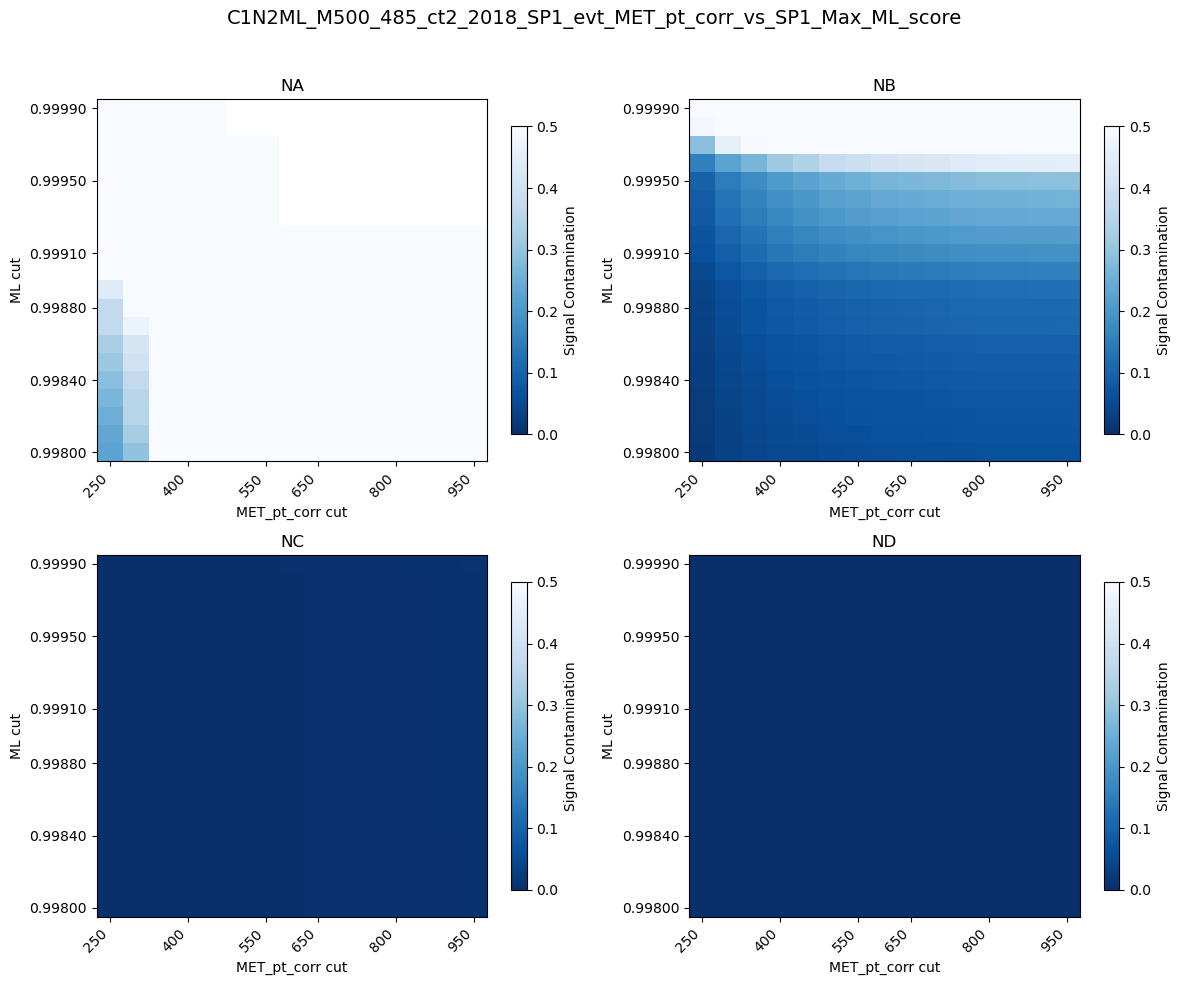

In [102]:
blinding_mask = (table[key]['sig_NB'] / table[key]['bkg_NB'] < 0.20)
import matplotlib.ticker as mtick

Z_KEYS = ["NA", "NB", "NC", "ND"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, ZK in zip(axes, Z_KEYS):

    s = table[key][f'sig_{ZK}']
    b = table[key][f'bkg_{ZK}']
    b[b < 0] = 0.1
    X_b = s / b
    X_b = X_b.loc[250:, 0.998:]

    x = X_b.index.to_numpy(dtype=float)
    y = X_b.columns.to_numpy(dtype=float)

    x_edges = edges_from_centers(x)
    y_edges = edges_from_centers(y)

    C = X_b.T.to_numpy()
    cmap = plt.cm.Blues_r.copy()
    pcm = ax.pcolormesh(
        x_edges, y_edges, C,
        cmap=cmap,
        vmin=0,
        vmax=0.5, # 50% signal contamination
        shading="flat"
    )

    ax.set_xticks(pick_ticks(x, 6))
    ax.set_yticks(pick_ticks(y, 6))

    ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()],
                       rotation=45, ha="right")
    ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

    ax.set_xlabel("MET_pt_corr cut")
    ax.set_ylabel("ML cut")
    ax.set_title(ZK)

    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.5f'))

    cbar = fig.colorbar(pcm, ax=ax, shrink=0.85)
    cbar.ax.set_ylabel("Signal Contamination")

fig.suptitle(SAMPLE, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
